# Первоначальная архитектура без аудио эмбеддингов

In [1]:
from dataframes import (
    load_existing_train_val_test_csv,
    remove_videos_by_path
)

train_df, val_df, test_df, track2idx, idx2track = load_existing_train_val_test_csv(
    train_csv_path="final_dataset_with_queries/train_with_queries.csv",
    val_csv_path="final_dataset_with_queries/val_with_queries.csv",
    test_csv_path="final_dataset_with_queries/test_with_queries.csv",
)

train_df = remove_videos_by_path(
    train_df,
    bad_video_paths=[
        r"OpenLAV\videos\514_The_Greatest_PC_Marketing_Pitch_of_All_Time.mp4"
    ],
)

Train size: 97920
Val size: 14400
Test size: 14400
Number of track classes: 60
Removed rows: 1440
Remaining rows: 96480


In [2]:
from precompute_embeddings import build_precomputed_embeddings


train_df, val_df, test_df = build_precomputed_embeddings(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    output_dir="training_artifacts/precomputed_videomae",
    video_root=r"C:\VS code projects\NLP lingua of internet\cv_project",
    text_model_name="intfloat/multilingual-e5-small",
    video_model_name="MCG-NJU/videomae-base-finetuned-kinetics",
    video_batch_size=1,
    num_frames=16,
    image_size=224,
    hf_pooling="mean",
    device="cuda",
    missing_video="error",
)

c:\VS code projects\NLP lingua of internet\cv_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unique queries: 2088


Encoding texts: 100%|██████████| 33/33 [00:01<00:00, 31.66it/s]


Unique video titles: 97


Encoding texts: 100%|██████████| 2/2 [00:00<00:00, 58.15it/s]


Unique videos: 97


Loading weights: 100%|██████████| 158/158 [00:00<00:00, 2897.77it/s]
[transformers] VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key                                                        | Status     | 
-----------------------------------------------------------+------------+-
videomae.encoder.layer.{0...11}.attention.attention.q_bias | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias | UNEXPECTED | 
fc_norm.weight                                             | UNEXPECTED | 
fc_norm.bias                                               | UNEXPECTED | 
classifier.weight                                          | UNEXPECTED | 
classifier.bias                                            | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias      | MISSING    | 
encoder.layer.{0...11}.attention.attention.query.bias      | MISSING    | 
encoder.layer.{0...11}.attention.attention.key.bias        | MISSING    | 

Notes:
- UNEXPECT

Saved precomputed embeddings to: training_artifacts\precomputed_videomae


In [ ]:
import json
from pathlib import Path

precomputed_dir = 'training_artifacts/precomputed_videomae'

with open(f"{precomputed_dir}/query2idx.json", "r", encoding="utf-8") as f:
    query2idx = json.load(f)

with open(f"{precomputed_dir}/title2idx.json", "r", encoding="utf-8") as f:
    title2idx = json.load(f)

with open(f"{precomputed_dir}/video2idx.json", "r", encoding="utf-8") as f:
    video2idx = json.load(f)


def add_precomputed_indices(df):
    df = df.copy()

    df["query_emb_idx"] = (
        df["query_id"]
        .astype(str)
        .map(query2idx)
    )

    df["title_emb_idx"] = (
        df["video_id"]
        .astype(str)
        .map(title2idx)
    )

    df["video_emb_idx"] = (
        df["video_id"]
        .astype(str)
        .map(video2idx)
    )

    missing = df[
        df["query_emb_idx"].isna()
        | df["title_emb_idx"].isna()
        | df["video_emb_idx"].isna()
    ]

    if len(missing) > 0:
        raise ValueError(
            f"Found {len(missing)} rows without precomputed embedding indices."
        )

    df["query_emb_idx"] = df["query_emb_idx"].astype(int)
    df["title_emb_idx"] = df["title_emb_idx"].astype(int)
    df["video_emb_idx"] = df["video_emb_idx"].astype(int)

    return df.reset_index(drop=True)


train_df = add_precomputed_indices(train_df)
val_df = add_precomputed_indices(val_df)
test_df = add_precomputed_indices(test_df)

In [9]:
train_df.to_pickle(f"{precomputed_dir}/train_top5_multilabel.pkl")
val_df.to_pickle(f"{precomputed_dir}/val_top5_multilabel.pkl")
test_df.to_pickle(f"{precomputed_dir}/test_top5_multilabel.pkl")

In [10]:
from data_loaders import create_precomputed_multilabel_loaders, PrecomputedMultilabelLoaderConfig

loader_config = PrecomputedMultilabelLoaderConfig(
    batch_size=128,
    duration_col="duration_s",
    labels_col="labels",
)

train_loader, val_loader, test_loader = create_precomputed_multilabel_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    precomputed_dir=precomputed_dir,
    config=loader_config,
)

In [11]:
batch = next(iter(train_loader))

for k, v in batch.items():
    print(k, v.shape)

query_features torch.Size([128, 384])
title_features torch.Size([128, 384])
video_features torch.Size([128, 768])
duration torch.Size([128])
labels torch.Size([128, 60])


In [12]:
import numpy as np
import json

precomputed_dir = "training_artifacts/precomputed_videomae"

video_embeddings = np.load(f"{precomputed_dir}/video_embeddings.npy")

with open(f"{precomputed_dir}/video2idx.json", "r", encoding="utf-8") as f:
    video2idx = json.load(f)

print("video_embeddings.shape:", video_embeddings.shape)
print("len(video2idx):", len(video2idx))
print("max video idx:", max(video2idx.values()))

print("train max video_emb_idx:", train_df["video_emb_idx"].max())
print("val max video_emb_idx:", val_df["video_emb_idx"].max())
print("test max video_emb_idx:", test_df["video_emb_idx"].max())

video_embeddings.shape: (97, 768)
len(video2idx): 97
max video idx: 96
train max video_emb_idx: 66
val max video_emb_idx: 81
test max video_emb_idx: 96


In [13]:
from architacture import (
    FusionModelConfig,
    PrecomputedTextPairBackbone,
    PrecomputedVideoBackbone,
    MusicMatchingModel,
)

query_embeddings_np = np.load(f"{precomputed_dir}/query_embeddings.npy")
title_embeddings_np = np.load(f"{precomputed_dir}/title_embeddings.npy")
video_embeddings_np = np.load(f"{precomputed_dir}/video_embeddings.npy")

query_dim = query_embeddings_np.shape[1]
title_dim = title_embeddings_np.shape[1]
video_dim = video_embeddings_np.shape[1]

config = FusionModelConfig(
    text_dim=256,
    video_dim=256,
    duration_dim=32,
    fusion_hidden_dim=512,
    fusion_output_dim=256,
    num_labels=num_labels,
    dropout=0.2,
    task_type="multilabel",
)

text_backbone = PrecomputedTextPairBackbone(
    query_input_dim=query_dim,
    title_input_dim=title_dim,
    encoder_output_dim=256,
    fusion_hidden_dim=512,
    fusion_output_dim=config.text_dim,
    dropout=0.2,
    use_interactions=True,
)

video_backbone = PrecomputedVideoBackbone(
    input_dim=video_dim,
    output_dim=config.video_dim,
)

model = MusicMatchingModel(
    text_backbone=text_backbone,
    video_backbone=video_backbone,
    config=config,
)

In [14]:
import os
from dataclasses import dataclass
from typing import Optional
from tqdm.auto import tqdm
from metrics import compute_topk_multilabel_metrics
import torch 


@dataclass
class MultilabelTrainConfig:
    num_epochs: int = 50
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4

    max_grad_norm: float = 1.0

    patience: int = 10
    min_delta: float = 1e-4

    early_stopping_metric: str = "recall@5"

    save_path: str = "training_artifacts/best_top5_multilabel_model.pt"

    use_amp: bool = True
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def move_batch_to_device(batch, device):
    result = {}

    for key, value in batch.items():
        if torch.is_tensor(value):
            result[key] = value.to(device)
        else:
            result[key] = value

    return result


def batch_without_labels(batch):
    return {
        k: v
        for k, v in batch.items()
        if k != "labels"
    }


def compute_pos_weight(train_df, num_labels, labels_col="labels"):
    labels_matrix = np.stack(
        train_df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values
    )

    positives = labels_matrix.sum(axis=0)
    negatives = labels_matrix.shape[0] - positives

    pos_weight = negatives / np.maximum(positives, 1)

    # чтобы редкие классы не давали слишком экстремальные веса
    pos_weight = np.clip(pos_weight, 1.0, 20.0)

    return torch.tensor(pos_weight, dtype=torch.float32)


@torch.no_grad()
def evaluate_multilabel(
    model,
    dataloader,
    criterion,
    config,
):
    device = torch.device(config.device)

    model.eval()

    total_loss = 0.0
    num_batches = 0

    all_labels = []
    all_probs = []

    progress_bar = tqdm(
        dataloader,
        desc="Validation",
        leave=False,
    )

    for batch in progress_bar:
        batch = move_batch_to_device(batch, device)

        labels = batch["labels"].float()

        output = model(batch_without_labels(batch))
        logits = output["logits"]
        probs = torch.sigmoid(logits)

        loss = criterion(logits, labels)

        total_loss += loss.item()
        num_batches += 1

        progress_bar.set_postfix(
            loss=total_loss / num_batches
        )

        all_labels.append(labels.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)

    metrics = {}
    metrics.update(compute_topk_multilabel_metrics(y_true, y_prob, k=3))
    metrics.update(compute_topk_multilabel_metrics(y_true, y_prob, k=5))

    metrics["loss"] = total_loss / max(num_batches, 1)

    return metrics, y_prob, y_true


def train_multilabel_model(
    model,
    train_loader,
    val_loader,
    train_df,
    num_labels,
    config=None,
):
    if config is None:
        config = MultilabelTrainConfig()

    device = torch.device(config.device)
    model = model.to(device)

    pos_weight = compute_pos_weight(
        train_df=train_df,
        num_labels=num_labels,
        labels_col="labels",
    ).to(device)

    criterion = torch.nn.BCEWithLogitsLoss(
        pos_weight=pos_weight,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )

    scaler = torch.amp.GradScaler(
        device.type,
        enabled=config.use_amp and device.type == "cuda",
    )

    best_metric = -float("inf")
    best_epoch = -1
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_precision@5": [],
        "val_recall@5": [],
        "val_hit@5": [],
        "val_f1@5": [],
    }

    save_dir = os.path.dirname(config.save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, config.num_epochs + 1):
        model.train()

        total_train_loss = 0.0
        num_train_batches = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch:03d}/{config.num_epochs}",
            leave=False,
        )

        for batch in progress_bar:
            batch = move_batch_to_device(batch, device)

            labels = batch["labels"].float()

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=config.use_amp and device.type == "cuda",
            ):
                output = model(batch_without_labels(batch))
                logits = output["logits"]
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=config.max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()
            num_train_batches += 1

            progress_bar.set_postfix(
                train_loss=total_train_loss / num_train_batches
            )

        train_loss = total_train_loss / max(num_train_batches, 1)

        val_metrics, y_prob_val, y_true_val = evaluate_multilabel(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            config=config,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_precision@5"].append(val_metrics["precision@5"])
        history["val_recall@5"].append(val_metrics["recall@5"])
        history["val_hit@5"].append(val_metrics["hit@5"])
        history["val_f1@5"].append(val_metrics["f1@5"])

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"p@5={val_metrics['precision@5']:.4f} | "
            f"r@5={val_metrics['recall@5']:.4f} | "
            f"hit@5={val_metrics['hit@5']:.4f} | "
            f"f1@5={val_metrics['f1@5']:.4f} | "
        )

        if config.early_stopping_metric not in val_metrics:
            raise ValueError(
                f"Unknown early_stopping_metric: {config.early_stopping_metric}. "
                f"Available metrics: {list(val_metrics.keys())}"
            )

        current_metric = val_metrics[config.early_stopping_metric]

        improved = current_metric > best_metric + config.min_delta

        if improved:
            best_metric = current_metric
            best_epoch = epoch
            patience_counter = 0

            checkpoint = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_metric": best_metric,
                "early_stopping_metric": config.early_stopping_metric,
                "config": config,
                "history": history,
                "track2idx": track2idx,
                "idx2track": idx2track,
            }

            torch.save(checkpoint, config.save_path)

            print(
                f"  New best model saved: "
                f"val_{config.early_stopping_metric}={best_metric:.4f}"
            )

        else:
            patience_counter += 1

            print(
                f"  No improvement. "
                f"Patience: {patience_counter}/{config.patience}"
            )

            if patience_counter >= config.patience:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Best epoch: {best_epoch}, "
                    f"best val_{config.early_stopping_metric}={best_metric:.4f}"
                )
                break

    if os.path.exists(config.save_path):
        checkpoint = torch.load(
            config.save_path,
            map_location=device,
            weights_only=False,
        )
        model.load_state_dict(checkpoint["model_state_dict"])

    return {
        "model": model,
        "history": history,
        "best_metric": best_metric,
        "best_epoch": best_epoch,
    }

In [15]:
train_config = MultilabelTrainConfig(
    num_epochs=250,
    learning_rate=3e-4,
    weight_decay=1e-4,
    patience=30,
    min_delta=1e-4,
    early_stopping_metric="f1@5",
    save_path="training_artifacts/best_target_binary_multilabel_model.pt",
    use_amp=True,
)

result = train_multilabel_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    train_df=train_df,
    num_labels=num_labels,
    config=train_config,
)

model = result["model"]
history = result["history"]

print("Best epoch:", result["best_epoch"])
print("Best f1@5:", result["best_metric"])

Epoch 001/250:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 001 | train_loss=0.9929 | val_loss=0.9774 | p@5=0.5476 | r@5=0.1204 | hit@5=0.7905 | f1@5=0.1974 | 
  New best model saved: val_f1@5=0.1974


Epoch 002 | train_loss=0.8676 | val_loss=0.9990 | p@5=0.3190 | r@5=0.0866 | hit@5=0.5000 | f1@5=0.1362 | 
  No improvement. Patience: 1/30


Epoch 003 | train_loss=0.7092 | val_loss=0.9247 | p@5=0.4267 | r@5=0.1116 | hit@5=0.5571 | f1@5=0.1769 | 
  No improvement. Patience: 2/30


Epoch 004 | train_loss=0.5920 | val_loss=0.7957 | p@5=0.6314 | r@5=0.1533 | hit@5=0.7238 | f1@5=0.2468 | 
  New best model saved: val_f1@5=0.2468


...

Epoch 051 | train_loss=0.0067 | val_loss=1.4516 | p@5=0.6933 | r@5=0.1656 | hit@5=0.7143 | f1@5=0.2674 | 
  No improvement. Patience: 26/30


Epoch 052 | train_loss=0.0064 | val_loss=1.4968 | p@5=0.6848 | r@5=0.1605 | hit@5=0.7095 | f1@5=0.2600 | 
  No improvement. Patience: 27/30


Epoch 053 | train_loss=0.0062 | val_loss=1.4552 | p@5=0.6895 | r@5=0.1642 | hit@5=0.7048 | f1@5=0.2652 | 
  No improvement. Patience: 28/30


Epoch 054 | train_loss=0.0061 | val_loss=1.5174 | p@5=0.6829 | r@5=0.1624 | hit@5=0.7048 | f1@5=0.2623 | 
  No improvement. Patience: 29/30


Epoch 055 | train_loss=0.0059 | val_loss=1.4739 | p@5=0.6914 | r@5=0.1648 | hit@5=0.7095 | f1@5=0.2662 | 
  No improvement. Patience: 30/30
Early stopping at epoch 55. Best epoch: 25, best val_f1@5=0.2831
Best epoch: 25
Best f1@5: 0.28306323175361764


In [16]:
pos_counts = train_df["labels"].apply(lambda x: np.asarray(x).sum())

print("Train positives:")
print(pos_counts.describe())

pos_counts_val = val_df["labels"].apply(lambda x: np.asarray(x).sum())

print("Val positives:")
print(pos_counts_val.describe())

Train positives:
count    1608.000000
mean       16.975746
std        12.353134
min         0.000000
25%         6.000000
50%        15.000000
75%        27.000000
max        40.000000
Name: labels, dtype: float64
Val positives:
count    240.000000
mean      19.424999
std       12.365874
min        0.000000
25%        8.000000
50%       20.000000
75%       32.000000
max       40.000000
Name: labels, dtype: float64


In [18]:
import torch

device = torch.device(train_config.device)
model = model.to(device)

pos_weight = compute_pos_weight(
    train_df=train_df,
    num_labels=num_labels,
    labels_col="labels",
).to(device)

criterion = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight,
)

test_metrics, y_prob_test, y_true_test = evaluate_multilabel(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    config=train_config,
)

print(test_metrics)

{'precision@3': 0.7032163742690057, 'recall@3': 0.18483948990241897, 'hit@3': 0.7456140350877193, 'f1@3': 0.29273418746508184, 'map@3': 0.7244152046783625, 'precision@5': 0.6877192982456141, 'recall@5': 0.267665488274756, 'hit@5': 0.7587719298245614, 'f1@5': 0.3853499121151434, 'map@5': 0.7192105263157895, 'loss': 0.9575375616550446}


In [48]:
{'precision@3': 0.7032163742690057, 'recall@3': 0.18483948990241897, 'hit@3': 0.7456140350877193, 'f1@3': 0.29273418746508184, 'map@3': 0.7244152046783625, 'precision@5': 0.6877192982456141, 'recall@5': 0.267665488274756, 'hit@5': 0.7587719298245614, 'f1@5': 0.3853499121151434, 'map@5': 0.7192105263157895, 'loss': 0.9575375616550446}


{'precision@3': 0.7032163742690057,
 'recall@3': 0.18483948990241897,
 'hit@3': 0.7456140350877193,
 'f1@3': 0.29273418746508184,
 'map@3': 0.7244152046783625,
 'precision@5': 0.6877192982456141,
 'recall@5': 0.267665488274756,
 'hit@5': 0.7587719298245614,
 'f1@5': 0.3853499121151434,
 'map@5': 0.7192105263157895,
 'loss': 0.9575375616550446}

In [19]:
def random_baseline_metrics(df, labels_col="labels", ks=(3, 5, 10), n_runs=100, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.stack(df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values)
    num_samples, num_classes = y_true.shape

    all_runs = []

    for _ in range(n_runs):
        y_prob = rng.random(size=(num_samples, num_classes))

        run_metrics = {}
        for k in ks:
            run_metrics.update(compute_topk_multilabel_metrics(y_true, y_prob, k=k))

        all_runs.append(run_metrics)

    result = {}

    for key in all_runs[0].keys():
        values = [run[key] for run in all_runs]
        result[key] = round(float(np.mean(values)), 3)

    return result


random_metrics = random_baseline_metrics(test_df, ks=(3, 5))
random_metrics

{'precision@3': 0.286,
 'recall@3': 0.05,
 'hit@3': 0.565,
 'f1@3': 0.085,
 'map@3': 0.221,
 'precision@5': 0.287,
 'recall@5': 0.084,
 'hit@5': 0.692,
 'f1@5': 0.129,
 'map@5': 0.197}

In [20]:
def frequency_baseline_metrics(train_df, eval_df, labels_col="labels", ks=(3, 5, 10)):
    y_train = np.stack(train_df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values)
    y_true = np.stack(eval_df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values)

    class_freq = y_train.mean(axis=0)

    y_prob = np.tile(class_freq[None, :], (len(eval_df), 1))

    metrics = {}
    for k in ks:
        metrics.update(compute_topk_multilabel_metrics(y_true, y_prob, k=k))

    return {key: round(value, 3) for key, value in metrics.items()}


freq_metrics = frequency_baseline_metrics(train_df, test_df, ks=(3, 5))
freq_metrics

{'precision@3': 0.395,
 'recall@3': 0.042,
 'hit@3': 0.395,
 'f1@3': 0.076,
 'map@3': 0.395,
 'precision@5': 0.395,
 'recall@5': 0.07,
 'hit@5': 0.395,
 'f1@5': 0.118,
 'map@5': 0.395}

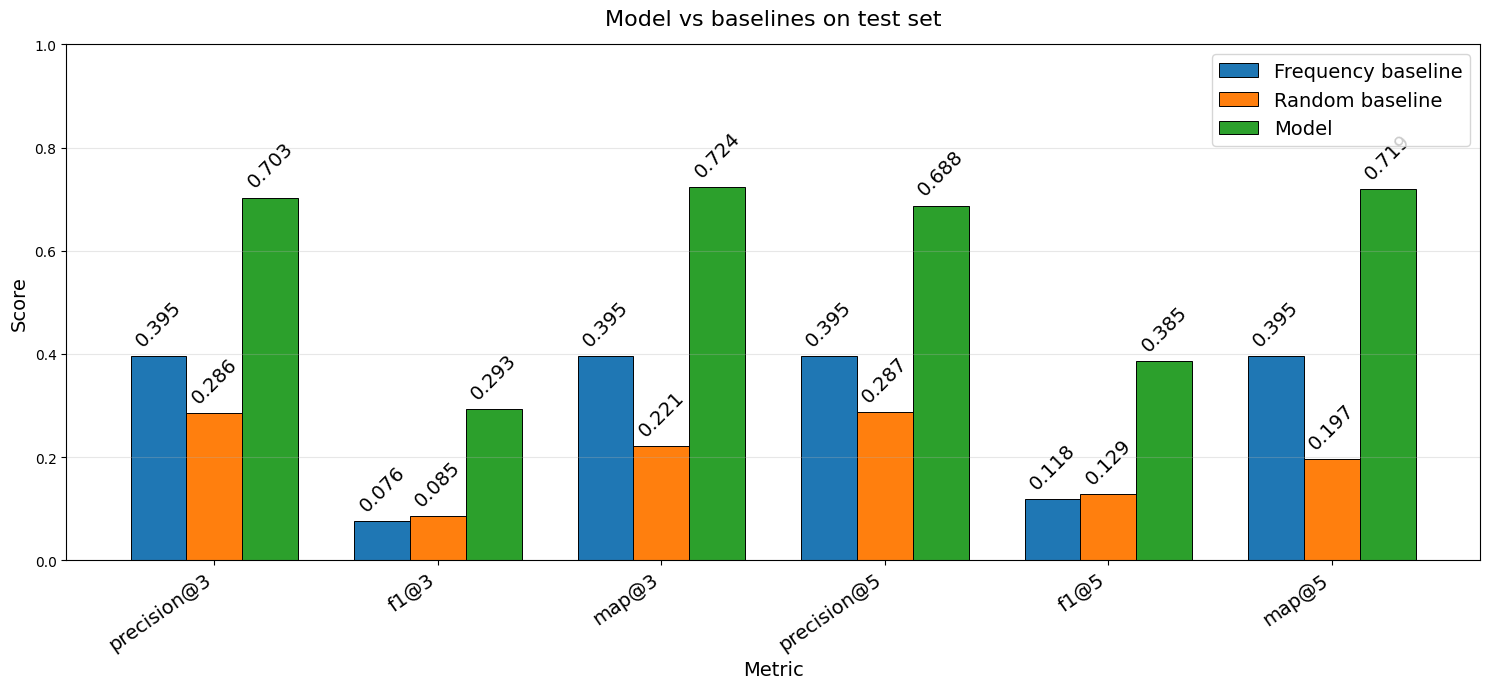

,Frequency baseline,Random baseline,Model
precision@3,0.395,0.286,0.703216
f1@3,0.076,0.085,0.292734
map@3,0.395,0.221,0.724415
precision@5,0.395,0.287,0.687719
f1@5,0.118,0.129,0.385350
map@5,0.395,0.197,0.719211


In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_metric_comparison(
    frequency_baseline,
    random_baseline,
    model_metrics,
    metric_names=None,
    title="Comparison of model and baselines",
    save_path=None,
):
    """
    Строит grouped bar chart для сравнения модели с бейзлайнами.

    frequency_baseline, random_baseline, model_metrics:
        dict с метриками.

    metric_names:
        список метрик для отображения.
        loss по умолчанию не используется, так как это не ranking-метрика.
    """

    if metric_names is None:
        metric_names = [
            "precision@3",
            "f1@3",
            "map@3",
            "precision@5",
            "f1@5",
            "map@5",
        ]

    data = pd.DataFrame(
        {
            "Frequency baseline": [frequency_baseline.get(m, np.nan) for m in metric_names],
            "Random baseline": [random_baseline.get(m, np.nan) for m in metric_names],
            "Model": [model_metrics.get(m, np.nan) for m in metric_names],
        },
        index=metric_names,
    )

    x = np.arange(len(metric_names))
    width = 0.25

    plt.figure(figsize=(15, 7))

    bars_freq = plt.bar(
        x - width,
        data["Frequency baseline"],
        width,
        label="Frequency baseline",
        edgecolor="black",
        linewidth=0.7,
    )

    bars_random = plt.bar(
        x,
        data["Random baseline"],
        width,
        label="Random baseline",
        edgecolor="black",
        linewidth=0.7,
    )

    bars_model = plt.bar(
        x + width,
        data["Model"],
        width,
        label="Model",
        edgecolor="black",
        linewidth=0.7,
    )

    for bars in [bars_freq, bars_random, bars_model]:
        for bar in bars:
            value = bar.get_height()

            if np.isnan(value):
                continue

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.012,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=14,
                rotation=45,
            )

    plt.title(title, fontsize=16, pad=14)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("Metric", fontsize=14)
    plt.xticks(x, metric_names, rotation=35, ha="right", fontsize=14)
    plt.ylim(0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    plt.legend(fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return data


comparison_df = plot_metric_comparison(
    frequency_baseline=freq_metrics,
    random_baseline=random_metrics,
    model_metrics=test_metrics,
    title="Model vs baselines on test set",
    save_path="training_artifacts/plots/model_vs_baselines.png",
)

display(comparison_df)

In [21]:
def add_num_positive(df, labels_col="labels"):
    df = df.copy()
    df["num_positive_tracks"] = df[labels_col].apply(lambda x: int(np.asarray(x).sum()))
    return df


test_df_with_pos = add_num_positive(test_df)

test_df_with_pos["num_positive_tracks"].describe()

count    240.000000
mean      16.250000
std       11.963858
min        0.000000
25%        6.750000
50%       15.000000
75%       26.250000
max       36.000000
Name: num_positive_tracks, dtype: float64

In [23]:
def get_example_quality_table(df, y_prob, labels_col="labels", k=5):
    y_true = np.stack(df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values)

    rows = []

    for i in range(len(df)):
        topk = np.argsort(y_prob[i])[-k:][::-1]
        true_set = set(np.where(y_true[i] == 1)[0])
        pred_set = set(topk)

        hits = len(true_set & pred_set)

        rows.append({
            "row_idx": i,
            "hits@k": hits,
            "precision@k": hits / k,
            "recall@k": hits / len(true_set) if len(true_set) > 0 else 0.0,
            "num_positive": len(true_set),
        })

    return pd.DataFrame(rows)


quality_df = get_example_quality_table(test_df, y_prob_test, k=5)

best_cases = quality_df.sort_values(["hits@k", "precision@k"], ascending=False).head(10)
worst_cases = quality_df.sort_values(["hits@k", "precision@k"], ascending=True).head(10)

In [24]:
def inspect_case(df, y_prob, idx2track, row_idx, labels_col="labels", k=10):
    row = df.iloc[row_idx]
    labels = np.asarray(row[labels_col], dtype=np.float32)

    topk = np.argsort(y_prob[row_idx])[-k:][::-1]

    rows = []

    for rank, class_idx in enumerate(topk, start=1):
        track_id = idx2track[class_idx]

        rows.append({
            "rank": rank,
            "track_id": track_id,
            "score": float(y_prob[row_idx, class_idx]),
            "is_relevant": int(labels[class_idx] == 1),
        })

    print("query_id:", row.get("query_id"))
    print("video_id:", row.get("video_id"))
    print("user_query:", row.get("user_query"))
    print("video_title:", row.get("video_title"))
    print("duration_s:", row.get("duration_s"))
    print("num_positive:", int(labels.sum()))

    return pd.DataFrame(rows)

In [43]:
case = worst_cases.iloc[4]
inspect_case(test_df, y_prob_test, idx2track, row_idx=int(case["row_idx"]), k=5)

row_idx: 48
query_id: 122__aggressive_intense__tpl_20
video_id: 122
user_query: нужна сильная и напористая музыка
video_title: PARANOIA - Short Horror Movie 2015
duration_s: 23.0
num_positive: 1


,rank,track_id,score,is_relevant
0,1,1073223,0.807572,0
1,2,1189144,0.780872,0
2,3,1313461,0.762220,0
3,4,800960,0.753422,0
4,5,1352999,0.753208,0


In [39]:
case = best_cases.iloc[0]
inspect_case(test_df, y_prob_test, idx2track, row_idx=int(case["row_idx"]), k=5)

row_idx: 3
query_id: 102__calm_relaxing__tpl_27
video_id: 102
user_query: хочу мягкое спокойное звучание
video_title: The Known - Short Horror Film (2014)
duration_s: 50.0
num_positive: 36


,rank,track_id,score,is_relevant
0,1,1073223,0.999024,1
1,2,1327694,0.998679,1
2,3,1352999,0.998435,1
3,4,262117,0.998424,1
4,5,800960,0.998364,1


## Визуализация

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt


def _to_float_dict(metrics):
    return {
        k: float(v)
        for k, v in metrics.items()
        if isinstance(v, (int, float, np.integer, np.floating))
    }


def _get_best_epoch_idx(history, best_epoch=None, metric_name=None, mode="max"):
    """
    Возвращает индекс лучшей эпохи в 0-based формате.
    Если best_epoch передан как 1-based номер эпохи, используем его.
    """
    if best_epoch is not None:
        return int(best_epoch) - 1

    if metric_name is not None and metric_name in history:
        values = np.asarray(history[metric_name], dtype=float)
        if mode == "min":
            return int(np.argmin(values))
        return int(np.argmax(values))

    if "val_loss" in history:
        return int(np.argmin(history["val_loss"]))

    return len(next(iter(history.values()))) - 1


def plot_test_metrics_bar(
    test_metrics,
    metric_names=None,
    title="Test metrics",
    save_path=None,
    ylim=(0, 1.0),
    sort_metrics=False,
):
    """
    Строит bar chart для test_metrics.

    test_metrics: dict, например:
        {
            "precision@3": 0.63,
            "recall@3": 0.20,
            ...
            "loss": 1.57
        }

    По умолчанию loss не рисуется, потому что он не лежит в диапазоне [0, 1].
    """
    metrics = _to_float_dict(test_metrics)

    if metric_names is None:
        metric_names = [
            key for key in metrics.keys()
            if key != "loss"
        ]

    metric_names = [
        key for key in metric_names
        if key in metrics
    ]

    values = [metrics[key] for key in metric_names]

    if sort_metrics:
        pairs = sorted(
            zip(metric_names, values),
            key=lambda x: x[1],
            reverse=True,
        )
        metric_names, values = zip(*pairs)
        metric_names = list(metric_names)
        values = list(values)

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        metric_names,
        values,
        edgecolor="black",
        linewidth=0.8,
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.title(title, fontsize=15, pad=12)
    plt.ylabel("Score", fontsize=12)
    plt.xlabel("Metric", fontsize=12)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_loss_until_best_epoch(
    history,
    best_epoch=None,
    best_metric_name=None,
    best_metric_mode="max",
    title="Train and validation loss until best epoch",
    save_path=None,
):
    """
    Строит train_loss и val_loss до лучшей эпохи включительно.
    """
    if "train_loss" not in history or "val_loss" not in history:
        raise ValueError("history must contain 'train_loss' and 'val_loss'.")

    best_idx = _get_best_epoch_idx(
        history=history,
        best_epoch=best_epoch,
        metric_name=best_metric_name,
        mode=best_metric_mode,
    )

    end_idx = best_idx + 1

    train_loss = np.asarray(history["train_loss"][:end_idx], dtype=float)
    val_loss = np.asarray(history["val_loss"][:end_idx], dtype=float)
    epochs = np.arange(1, end_idx + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        train_loss,
        marker="o",
        linewidth=2,
        label="Train loss",
    )

    plt.plot(
        epochs,
        val_loss,
        marker="o",
        linewidth=2,
        label="Validation loss",
    )

    plt.axvline(
        best_idx + 1,
        linestyle="--",
        linewidth=1.5,
        label=f"Best epoch: {best_idx + 1}",
    )

    plt.scatter(
        [best_idx + 1],
        [val_loss[best_idx]],
        s=90,
        zorder=5,
    )

    plt.text(
        best_idx + 1,
        val_loss[best_idx],
        f"  val={val_loss[best_idx]:.3f}",
        va="center",
        fontsize=10,
    )

    plt.title(title, fontsize=15, pad=12)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.xticks(epochs)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_history_metrics_until_best_epoch(
    history,
    metric_names=None,
    best_epoch=None,
    best_metric_name=None,
    best_metric_mode="max",
    title="Validation metrics until best epoch",
    save_path=None,
    ylim=(0, 1.0),
):
    """
    Рисует несколько validation-метрик по эпохам до лучшей эпохи включительно.
    """
    if metric_names is None:
        metric_names = [
            key for key in history.keys()
            if key.startswith("val_") and key != "val_loss"
        ]

    metric_names = [
        key for key in metric_names
        if key in history
    ]

    if len(metric_names) == 0:
        raise ValueError("No metric_names found in history.")

    best_idx = _get_best_epoch_idx(
        history=history,
        best_epoch=best_epoch,
        metric_name=best_metric_name,
        mode=best_metric_mode,
    )

    end_idx = best_idx + 1
    epochs = np.arange(1, end_idx + 1)

    plt.figure(figsize=(12, 7))

    for metric_name in metric_names:
        values = np.asarray(history[metric_name][:end_idx], dtype=float)

        plt.plot(
            epochs,
            values,
            marker="o",
            linewidth=2,
            label=metric_name.replace("val_", ""),
        )

    plt.axvline(
        best_idx + 1,
        linestyle="--",
        linewidth=1.5,
        label=f"Best epoch: {best_idx + 1}",
    )

    plt.title(title, fontsize=15, pad=12)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Score", fontsize=12)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(epochs)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, ncol=2)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def plot_single_history_metric_until_best_epoch(
    history,
    metric_name,
    best_epoch=None,
    best_metric_name=None,
    best_metric_mode="max",
    title=None,
    save_path=None,
    ylim=(0, 1.0),
):
    """
    Отдельный график одной метрики по эпохам.
    Удобно, если много линий на одном графике выглядит перегруженно.
    """
    if metric_name not in history:
        raise ValueError(f"{metric_name} not found in history.")

    best_idx = _get_best_epoch_idx(
        history=history,
        best_epoch=best_epoch,
        metric_name=best_metric_name,
        mode=best_metric_mode,
    )

    end_idx = best_idx + 1
    epochs = np.arange(1, end_idx + 1)
    values = np.asarray(history[metric_name][:end_idx], dtype=float)

    best_value_idx = int(np.argmax(values))
    best_value = float(values[best_value_idx])

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        values,
        marker="o",
        linewidth=2,
        label=metric_name,
    )

    plt.axvline(
        best_idx + 1,
        linestyle="--",
        linewidth=1.5,
        label=f"Selected best epoch: {best_idx + 1}",
    )

    plt.scatter(
        [best_value_idx + 1],
        [best_value],
        s=90,
        zorder=5,
    )

    plt.text(
        best_value_idx + 1,
        best_value,
        f"  max={best_value:.3f}",
        va="center",
        fontsize=10,
    )

    plt.title(title or metric_name, fontsize=15, pad=12)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Score", fontsize=12)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(epochs)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

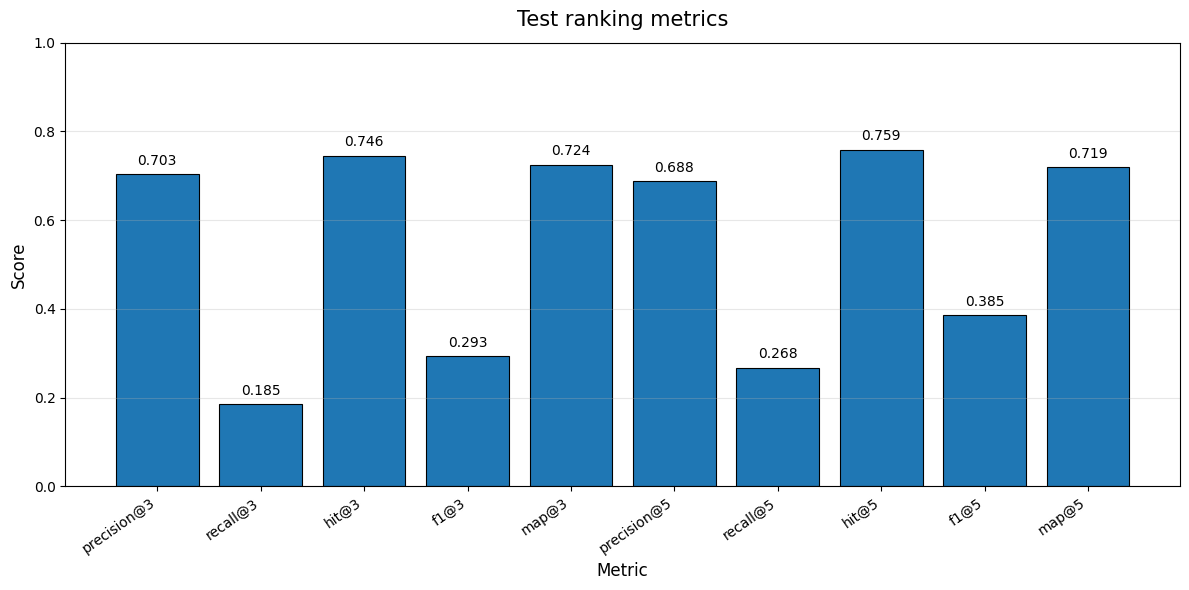

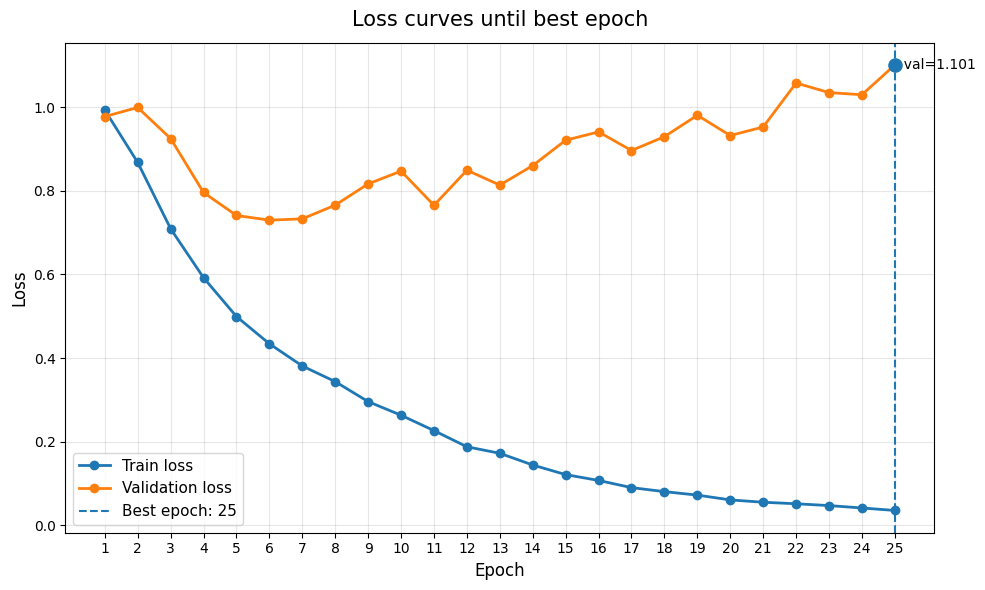

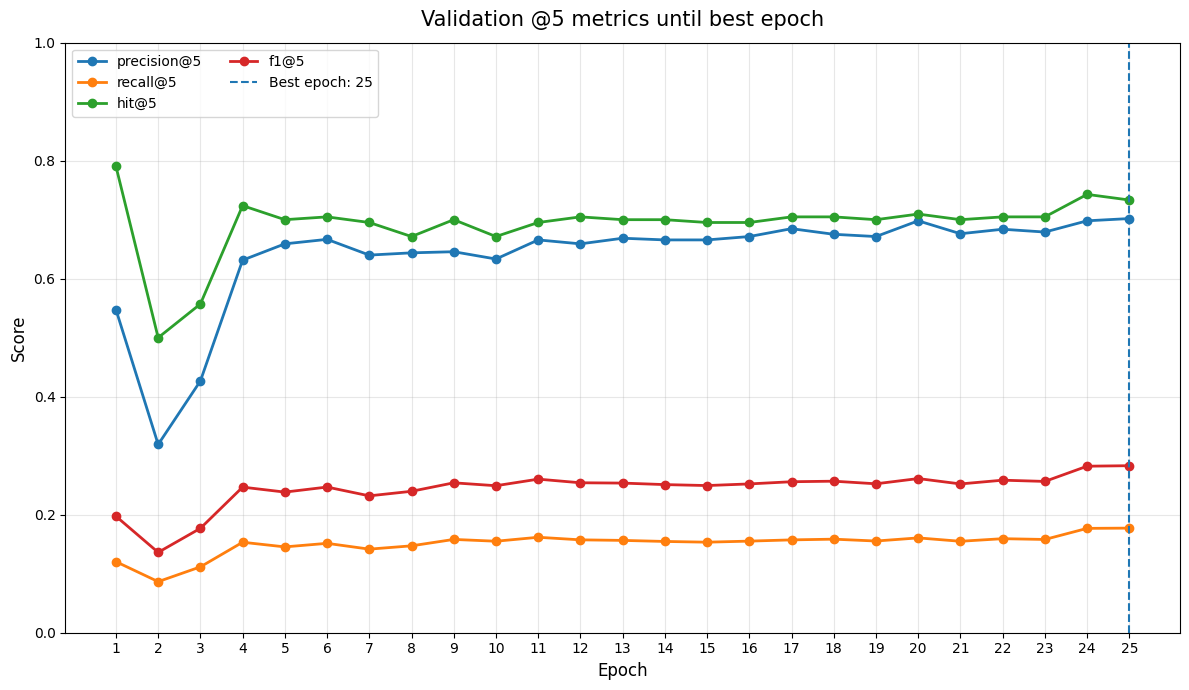

In [29]:
# Например, если result содержит best_epoch:
best_epoch = result["best_epoch"]

plot_test_metrics_bar(
    test_metrics,
    metric_names=[
        "precision@3",
        "recall@3",
        "hit@3",
        "f1@3",
        "map@3",
        "precision@5",
        "recall@5",
        "hit@5",
        "f1@5",
        "map@5"
    ],
    title="Test ranking metrics",
    save_path="training_artifacts/metrics/test_metrics_bar.png",
)

plot_loss_until_best_epoch(
    history,
    best_epoch=best_epoch,
    title="Loss curves until best epoch",
    save_path="training_artifacts/metrics/loss_until_best_epoch.png",
)

plot_history_metrics_until_best_epoch(
    history,
    metric_names=[
        "val_precision@5",
        "val_recall@5",
        "val_hit@5",
        "val_f1@5",
        "val_map@5",
    ],
    best_epoch=best_epoch,
    title="Validation @5 metrics until best epoch",
    save_path="training_artifacts/metrics/val_metrics_at5_until_best_epoch.png",
)

### Просмотр ошибок

In [34]:
import numpy as np
import pandas as pd


def build_case_quality_df(df, y_prob, labels_col="labels", k=5):
    y_true = np.stack(
        df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values
    )

    rows = []

    for i in range(len(df)):
        labels = y_true[i]
        topk = np.argsort(y_prob[i])[-k:][::-1]

        true_set = set(np.where(labels == 1)[0])
        pred_set = set(topk)

        hits = len(true_set & pred_set)

        if len(true_set) == 0:
            recall = np.nan
            hit = np.nan
        else:
            recall = hits / len(true_set)
            hit = float(hits > 0)

        precision = hits / k

        rows.append({
            "row_idx": i,
            "query_id": df.iloc[i].get("query_id"),
            "video_id": df.iloc[i].get("video_id"),
            "user_query": df.iloc[i].get("user_query"),
            "video_title": df.iloc[i].get("video_title"),
            "num_positive": int(labels.sum()),
            f"hits@{k}": hits,
            f"precision@{k}": precision,
            f"recall@{k}": recall,
            f"hit@{k}": hit,
        })

    return pd.DataFrame(rows)


quality_df = build_case_quality_df(
    df=test_df,
    y_prob=y_prob_test,
    labels_col="labels",
    k=5,
)

best_cases = quality_df.sort_values("precision@5", ascending=False).head()
worst_cases = quality_df.sort_values("precision@5", ascending=True).head()

display(best_cases)
display(worst_cases)

,row_idx,query_id,video_id,user_query,video_title,num_positive,hits@5,precision@5,recall@5,hit@5
3,3,102__calm_relaxing__tpl_27,102,хочу мягкое спокойное звучание,The Known - Short Horror Film (2014),36,5,1.0,0.138889,1.0
2,2,102__calm_relaxing__tpl_19,102,подбери легкую фоновую музыку,The Known - Short Horror Film (2014),36,5,1.0,0.138889,1.0
6,6,102__dreamy_atmospheric__tpl_4,102,подбери музыку с воздушной атмосферой,The Known - Short Horror Film (2014),36,5,1.0,0.138889,1.0
7,7,102__dreamy_atmospheric__tpl_9,102,хочу мягкий dreamy soundtrack,The Known - Short Horror Film (2014),36,5,1.0,0.138889,1.0
12,12,102__romantic_warm__tpl_0,102,хочу теплую романтичную музыку,The Known - Short Horror Film (2014),24,5,1.0,0.208333,1.0


,row_idx,query_id,video_id,user_query,video_title,num_positive,hits@5,precision@5,recall@5,hit@5
1,1,102__aggressive_intense__tpl_24,102,хочу интенсивный фон без спокойствия,The Known - Short Horror Film (2014),1,0,0.0,0.0,0.0
4,4,102__dark_tense__tpl_16,102,подбери dark ambient трек,The Known - Short Horror Film (2014),4,0,0.0,0.0,0.0
5,5,102__dark_tense__tpl_7,102,подбери драматичный cinematic трек,The Known - Short Horror Film (2014),4,0,0.0,0.0,0.0
43,43,121__happy_upbeat__tpl_9,121,"хочу музыку, которая звучит радостно и тепло",Darkness (Short Horror Film),21,0,0.0,0.0,0.0
48,48,122__aggressive_intense__tpl_20,122,нужна сильная и напористая музыка,PARANOIA - Short Horror Movie 2015,1,0,0.0,0.0,0.0


In [31]:
def inspect_case(
    df,
    y_prob,
    idx2track,
    row_idx,
    labels_col="labels",
    k=10,
    track_metadata_df=None,
):
    row = df.iloc[row_idx]
    labels = np.asarray(row[labels_col], dtype=np.float32)

    topk = np.argsort(y_prob[row_idx])[-k:][::-1]

    rows = []

    for rank, class_idx in enumerate(topk, start=1):
        track_id = str(idx2track[class_idx])

        item = {
            "rank": rank,
            "track_id": track_id,
            "score": float(y_prob[row_idx, class_idx]),
            "is_relevant": int(labels[class_idx] == 1),
        }

        if track_metadata_df is not None:
            meta = track_metadata_df[
                track_metadata_df["track_id"].astype(str) == track_id
            ]

            if len(meta) > 0:
                meta = meta.iloc[0]
                for col in ["audio_path", "selected_genre", "audio_category"]:
                    if col in meta:
                        item[col] = meta[col]

        rows.append(item)

    print("row_idx:", row_idx)
    print("query_id:", row.get("query_id"))
    print("video_id:", row.get("video_id"))
    print("user_query:", row.get("user_query"))
    print("video_title:", row.get("video_title"))
    print("duration_s:", row.get("duration_s"))
    print("num_positive:", int(labels.sum()))

    return pd.DataFrame(rows)

In [35]:
import pandas as pd

raw_train_df = pd.read_csv("final_dataset_with_queries/train_with_queries.csv")
raw_val_df = pd.read_csv("final_dataset_with_queries/val_with_queries.csv")
raw_test_df = pd.read_csv("final_dataset_with_queries/test_with_queries.csv")

raw_all_df = pd.concat(
    [raw_train_df, raw_val_df, raw_test_df],
    ignore_index=True,
)

track_metadata_df = (
    raw_all_df[
        [
            "track_id",
            "audio_path",
            "selected_genre",
            "audio_category",
            "query_audio_category",
        ]
    ]
    .drop_duplicates("track_id")
    .reset_index(drop=True)
)

track_metadata_df.head()

,track_id,audio_path,selected_genre,audio_category,query_audio_category
0,1068617,MTG_Jamendo_50\audio\soundtrack\1068617.opus,soundtrack,dark_tense,aggressive_intense
1,680974,MTG_Jamendo_50\audio\soundtrack\680974.opus,soundtrack,dark_tense,aggressive_intense
2,778561,MTG_Jamendo_50\audio\soundtrack\778561.opus,soundtrack,dark_tense,aggressive_intense
3,874646,MTG_Jamendo_50\audio\soundtrack\874646.opus,soundtrack,dark_tense,aggressive_intense
4,1108284,MTG_Jamendo_50\audio\soundtrack\1108284.opus,soundtrack,sad_melancholic,aggressive_intense


In [36]:
bad_idx = int(worst_cases.iloc[0]["row_idx"])

bad_case_table = inspect_case(
    df=test_df,
    y_prob=y_prob_test,
    idx2track=idx2track,
    row_idx=bad_idx,
    k=10,
    track_metadata_df=track_metadata_df,
)

display(bad_case_table)

row_idx: 1
query_id: 102__aggressive_intense__tpl_24
video_id: 102
user_query: хочу интенсивный фон без спокойствия
video_title: The Known - Short Horror Film (2014)
duration_s: 50.0
num_positive: 1


,rank,track_id,score,is_relevant,audio_path,selected_genre,audio_category
0,1,1073223,0.446681,0,MTG_Jamendo_50\audio\easylistening\1073223.opus,easylistening,calm_relaxing
1,2,1266576,0.429280,0,MTG_Jamendo_50\audio\chillout\1266576.opus,chillout,calm_relaxing
2,3,262075,0.424128,0,MTG_Jamendo_50\audio\folk\262075.opus,folk,calm_relaxing
3,4,1313461,0.407648,0,MTG_Jamendo_50\audio\chillout\1313461.opus,chillout,calm_relaxing
4,5,1352999,0.403717,0,MTG_Jamendo_50\audio\chillout\1352999.opus,chillout,calm_relaxing
5,6,1189144,0.391491,0,MTG_Jamendo_50\audio\easylistening\1189144.opus,easylistening,calm_relaxing
6,7,856980,0.375149,0,MTG_Jamendo_50\audio\folk\856980.opus,folk,calm_relaxing
7,8,1171147,0.358038,0,MTG_Jamendo_50\audio\classical\1171147.opus,classical,calm_relaxing
8,9,1059974,0.357446,0,MTG_Jamendo_50\audio\classical\1059974.opus,classical,calm_relaxing
9,10,1095111,0.352611,0,MTG_Jamendo_50\audio\chillout\1095111.opus,chillout,calm_relaxing


In [45]:
from collections import Counter


def analyze_category_errors(
    df,
    y_prob,
    idx2track,
    track_metadata_df,
    labels_col="labels",
    category_col="audio_category",
    k=5,
):
    track_meta = track_metadata_df.copy()
    track_meta["track_id"] = track_meta["track_id"].astype(str)
    track_to_cat = dict(zip(track_meta["track_id"], track_meta[category_col]))

    y_true = np.stack(
        df[labels_col].apply(lambda x: np.asarray(x, dtype=np.float32)).values
    )

    fp_counter = Counter()
    fn_counter = Counter()
    tp_counter = Counter()

    for i in range(len(df)):
        labels = y_true[i]
        topk = np.argsort(y_prob[i])[-k:][::-1]

        true_set = set(np.where(labels == 1)[0])
        pred_set = set(topk)

        tp = true_set & pred_set
        fp = pred_set - true_set
        fn = true_set - pred_set

        for idx in tp:
            track_id = str(idx2track[idx])
            tp_counter[track_to_cat.get(track_id, "unknown")] += 1

        for idx in fp:
            track_id = str(idx2track[idx])
            fp_counter[track_to_cat.get(track_id, "unknown")] += 1

        for idx in fn:
            track_id = str(idx2track[idx])
            fn_counter[track_to_cat.get(track_id, "unknown")] += 1

    rows = []

    categories = sorted(
        set(tp_counter) | set(fp_counter) | set(fn_counter)
    )

    for cat in categories:
        tp = tp_counter[cat]
        fp = fp_counter[cat]
        fn = fn_counter[cat]

        precision_like = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_like = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        rows.append({
            "category": cat,
            "tp_in_topk": tp,
            "fp_in_topk": fp,
            "fn_not_in_topk": fn,
            "topk_precision_by_category": precision_like,
            "topk_recall_by_category": recall_like,
        })

    return pd.DataFrame(rows).sort_values(
        ["fp_in_topk", "fn_not_in_topk"],
        ascending=False,
    )


category_errors_df = analyze_category_errors(
    df=test_df,
    y_prob=y_prob_test,
    idx2track=idx2track,
    track_metadata_df=track_metadata_df,
    category_col="audio_category",
    k=5,
)

display(category_errors_df)

,category,tp_in_topk,fp_in_topk,fn_not_in_topk,topk_precision_by_category,topk_recall_by_category
1,calm_relaxing,230,144,1570,0.614973,0.127778
3,dreamy_atmospheric,161,72,583,0.690987,0.216398
2,dark_tense,191,68,321,0.737452,0.373047
5,happy_upbeat,113,61,223,0.649425,0.336310
7,sad_melancholic,33,48,159,0.407407,0.171875
6,romantic_warm,23,11,71,0.676471,0.244681
4,energetic_electronic,0,11,54,0.000000,0.000000
0,aggressive_intense,33,1,135,0.970588,0.196429


In [46]:
def assign_query_type(query: str) -> str:
    q = str(query).lower()

    if any(w in q for w in ["спокой", "calm", "relax", "расслаб"]):
        return "calm_relaxing_query"

    if any(w in q for w in ["груст", "sad", "melancholic", "меланх"]):
        return "sad_melancholic_query"

    if any(w in q for w in ["энерг", "dynamic", "drive", "драйв", "sport"]):
        return "energetic_query"

    if any(w in q for w in ["рок", "rock", "metal"]):
        return "rock_query"

    if any(w in q for w in ["электрон", "electronic", "edm", "techno"]):
        return "electronic_query"

    if any(w in q for w in ["атмосфер", "ambient", "dreamy"]):
        return "atmospheric_query"

    return "other"


def analyze_by_query_type(quality_df):
    df = quality_df.copy()
    df["query_type"] = df["user_query"].apply(assign_query_type)

    return (
        df
        .groupby("query_type")
        .agg(
            num_examples=("row_idx", "count"),
            mean_precision_at5=("precision@5", "mean"),
            mean_recall_at5=("recall@5", "mean"),
            mean_hit_at5=("hit@5", "mean"),
            mean_num_positive=("num_positive", "mean"),
        )
        .reset_index()
        .sort_values("mean_precision_at5", ascending=False)
    )


query_type_analysis_df = analyze_by_query_type(quality_df)
display(query_type_analysis_df)

,query_type,num_examples,mean_precision_at5,mean_recall_at5,mean_hit_at5,mean_num_positive
6,sad_melancholic_query,16,0.912500,0.187229,0.937500,27.625000
1,calm_relaxing_query,22,0.772727,0.168188,0.772727,23.909091
5,rock_query,3,0.733333,0.629630,1.000000,8.333333
2,electronic_query,13,0.692308,0.541880,0.923077,8.846154
4,other,150,0.642667,0.256272,0.739437,15.286667
0,atmospheric_query,21,0.619048,0.190697,0.650000,19.190476
3,energetic_query,15,0.306667,0.432835,0.666667,6.400000


In [47]:
def analyze_by_positive_count_bins(quality_df):
    df = quality_df.copy()

    bins = [-1, 0, 5, 10, 20, 40, 100]
    labels = ["0", "1-5", "6-10", "11-20", "21-40", "40+"]

    df["positive_count_bin"] = pd.cut(
        df["num_positive"],
        bins=bins,
        labels=labels,
    )

    return (
        df
        .groupby("positive_count_bin", observed=True)
        .agg(
            num_examples=("row_idx", "count"),
            mean_precision_at5=("precision@5", "mean"),
            mean_recall_at5=("recall@5", "mean"),
            mean_hit_at5=("hit@5", "mean"),
        )
        .reset_index()
    )


positive_count_analysis_df = analyze_by_positive_count_bins(quality_df)
display(positive_count_analysis_df)

,positive_count_bin,num_examples,mean_precision_at5,mean_recall_at5,mean_hit_at5
0,0,12,0.000000,NaN,NaN
1,1-5,30,0.200000,0.483333,0.533333
2,6-10,68,0.511765,0.312733,0.558824
3,11-20,40,0.790000,0.268939,0.825000
4,21-40,90,0.937778,0.161159,0.955556


In [62]:
import torch

file_path = r"model_weights\best_target_binary_multilabel_model.pt"

# Отключаем weights_only (ставим False)
checkpoint = torch.load(file_path, map_location=torch.device('cpu'), weights_only=False)

print("Файл загружен в небезопасном режиме.")
print("Ключи в файле:", checkpoint.keys())


Файл загружен в небезопасном режиме.
Ключи в файле: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_metric', 'early_stopping_metric', 'config', 'history', 'track2idx', 'idx2track'])


In [3]:
import torch
from pathlib import Path

old_path = "C:\\VS code projects\\NLP lingua of internet\\cv_project\\model_weights\\best_target_binary_multilabel_model.pt"
new_path = "C:\\VS code projects\\NLP lingua of internet\\cv_project\\model_weights\\best_target_binary_multilabel_model_inference.pt"

class MultilabelTrainConfig:
    pass


torch.serialization.add_safe_globals([MultilabelTrainConfig])

checkpoint = torch.load(
    old_path,
    map_location="cpu",
    weights_only=False,
)

inference_checkpoint = {
    "model_state_dict": checkpoint["model_state_dict"],
    "track2idx": checkpoint["track2idx"],
    "idx2track": checkpoint.get("idx2track"),
    "best_metric": checkpoint.get("best_metric"),
    "epoch": checkpoint.get("epoch"),
    "early_stopping_metric": checkpoint.get("early_stopping_metric"),
}

torch.save(inference_checkpoint, new_path)

print("Saved inference checkpoint:", new_path)

Saved inference checkpoint: C:\VS code projects\NLP lingua of internet\cv_project\model_weights\best_target_binary_multilabel_model_inference.pt
